### ***`CRYPTOCURRENCY PRICE PREDICTION `***


---

Using machine learning algorithms



---


## 1. Importing Libraries

---



In [ ]:
# Importing essential libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier, VotingRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, mean_absolute_error


---
## 2. Loading Dataset
---

In [ ]:
# Loading the cryptocurrency historical prices dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/coin_Bitcoin.csv')



---
## 3. Dataset Preview
---

In [ ]:
df

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.000000e+00,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.000000e+00,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.000000e+00,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.000000e+00,1.085995e+09
...,...,...,...,...,...,...,...,...,...,...
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11


In [ ]:
df.head()
df.tail()


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11
2990,2991,Bitcoin,BTC,2021-07-06 23:59:59,35038.536363,33599.916169,33723.509655,34235.193451,2.650126e+10,6.418992e+11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2991 non-null   int64  
 1   Name       2991 non-null   object 
 2   Symbol     2991 non-null   object 
 3   Date       2991 non-null   object 
 4   High       2991 non-null   float64
 5   Low        2991 non-null   float64
 6   Open       2991 non-null   float64
 7   Close      2991 non-null   float64
 8   Volume     2991 non-null   float64
 9   Marketcap  2991 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 233.8+ KB


In [ ]:
df.isnull().sum()

,0
SNo,0
Name,0
Symbol,0
Date,0
High,0
Low,0
Open,0
Close,0
Volume,0
Marketcap,0


---
## 4. Data processing and data cleaning
---

In [ ]:
# Converting Date column to datetime format and setting it as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)


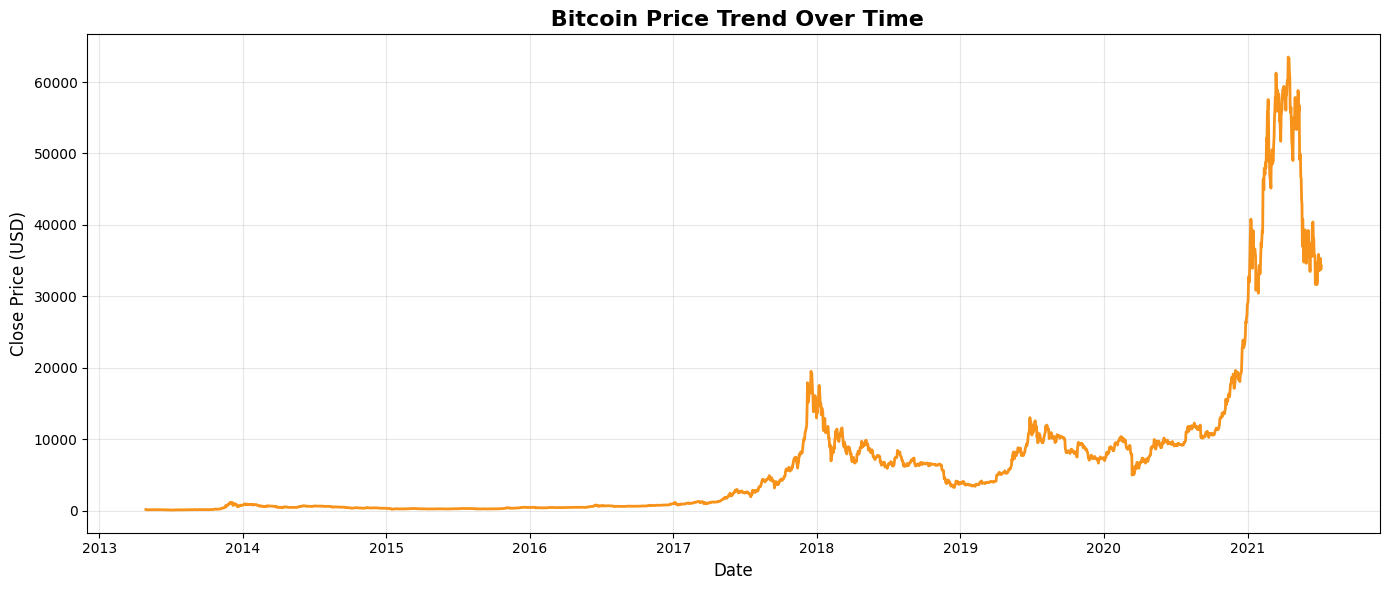

In [ ]:
# Visualizing Bitcoin closing price trend over time
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], color='#F7931A', linewidth=2)
plt.title(' Bitcoin Price Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

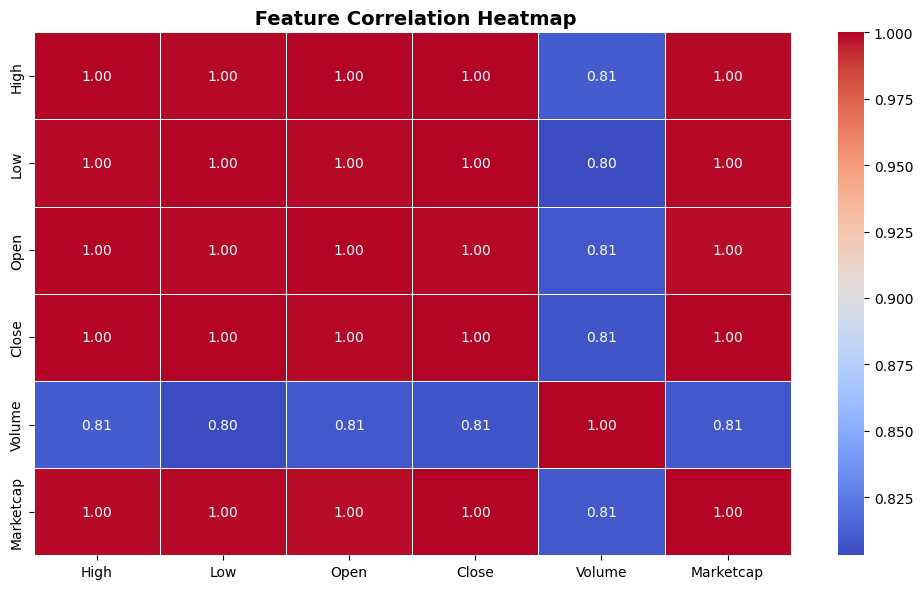

In [ ]:
# Visualizing correlation heatmap between features
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['SNo', 'Name', 'Symbol']).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(' Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


----
## 5. EDA (exploratory data analysis)
---

Creating new columns for better prediction
---

In [ ]:
# Creating technical indicators and features for better price prediction
df['Price_Change'] = df['Close'].pct_change()
df['High_Low'] = df['High'] - df['Low']
df['Price_Range'] = (df['High'] - df['Low']) / df['Close']
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()
df['Volatility'] = df['Close'].rolling(window=7).std()
df['Volume_Change'] = df['Volume'].pct_change()


df.head(25)

,SNo,Name,Symbol,High,Low,Open,Close,Volume,Marketcap,Price_Change,High_Low,Price_Range,MA_7,MA_21,Volatility,Volume_Change
Date,,,,,,,,,,,,,,,,
2013-04-29 23:59:59,1,Bitcoin,BTC,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09,NaN,13.488007,0.093317,NaN,NaN,NaN,NaN
2013-04-30 23:59:59,2,Bitcoin,BTC,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09,-0.038328,12.879990,0.092662,NaN,NaN,NaN,NaN
2013-05-01 23:59:59,3,Bitcoin,BTC,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09,-0.158345,32.169998,0.274981,NaN,NaN,NaN,NaN
2013-05-02 23:59:59,4,Bitcoin,BTC,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09,-0.100692,33.318100,0.316682,NaN,NaN,NaN,NaN
2013-05-03 23:59:59,5,Bitcoin,BTC,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09,-0.070906,29.028000,0.296962,NaN,NaN,NaN,NaN
2013-05-04 23:59:59,6,Bitcoin,BTC,115.000000,92.500000,98.099998,112.500000,0.0,1.250317e+09,0.150895,22.500000,0.200000,NaN,NaN,NaN,NaN
2013-05-05 23:59:59,7,Bitcoin,BTC,118.800003,107.142998,112.900002,115.910004,0.0,1.288693e+09,0.030311,11.657005,0.100569,118.842856,NaN,17.076705,NaN
2013-05-06 23:59:59,8,Bitcoin,BTC,124.663002,106.639999,115.980003,112.300003,0.0,1.249023e+09,-0.031145,18.023003,0.160490,114.237143,NaN,12.804043,NaN
2013-05-07 23:59:59,9,Bitcoin,BTC,113.444000,97.699997,112.250000,111.500000,0.0,1.240594e+09,-0.007124,15.744003,0.141202,110.308572,NaN,6.707189,NaN


---
##6.Preparing Data for Model
---
 Target Variable for Classification and Regression

---

In [ ]:
# Creating target variable for classification (1=Price UP, 0=Price DOWN)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)


In [ ]:
# Creating target variable for regression (next day's closing price)
df['Next_Close'] = df['Close'].shift(-1)

df[['Close', 'Next_Close', 'Target']].tail(10)

,Close,Next_Close,Target
Date,,,
2021-06-27 23:59:59,34649.644588,34434.335314,0
2021-06-28 23:59:59,34434.335314,35867.777735,1
2021-06-29 23:59:59,35867.777735,35040.837249,0
2021-06-30 23:59:59,35040.837249,33572.117653,0
2021-07-01 23:59:59,33572.117653,33897.048590,1
2021-07-02 23:59:59,33897.048590,34668.548402,1
2021-07-03 23:59:59,34668.548402,35287.779766,1
2021-07-04 23:59:59,35287.779766,33746.002456,0
2021-07-05 23:59:59,33746.002456,34235.193451,1


In [ ]:
# Removing rows with missing values after feature engineering
df = df.dropna()

---
##7. Train-test split
---

In [ ]:
# Selecting relevant features for model training
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume',
                   'Price_Change', 'High_Low', 'Price_Range',
                   'MA_7', 'MA_21', 'Volatility', 'Volume_Change']

X = df[feature_columns]
y_class = df['Target']       # For Classification
y_reg = df['Next_Close']     # For Regression


In [ ]:
# Splitting data into training (80%) and testing (20%) sets
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, shuffle=False)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42, shuffle=False)

print(X_train.shape[0])
print(X_test.shape[0])

2198
550


In [ ]:
# Scaling features for better model performance
scaler = StandardScaler()

# Handle infinite values before scaling
# Replace inf with NaN in X_train and X_test
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Get indices of rows with NaN (originally inf) in X_train
nan_rows_train = X_train.isnull().any(axis=1)
# Drop rows with NaN from X_train and corresponding y sets
X_train = X_train[~nan_rows_train]
y_train_class = y_train_class[~nan_rows_train]
y_train_reg = y_train_reg[~nan_rows_train]

# Get indices of rows with NaN (originally inf) in X_test
nan_rows_test = X_test.isnull().any(axis=1)
# Drop rows with NaN from X_test and corresponding y sets
X_test = X_test[~nan_rows_test]
y_test_class = y_test_class[~nan_rows_test]
y_test_reg = y_test_reg[~nan_rows_test]

# Now, scale the cleaned data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



/tmp/ipykernel_5128/3971761814.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


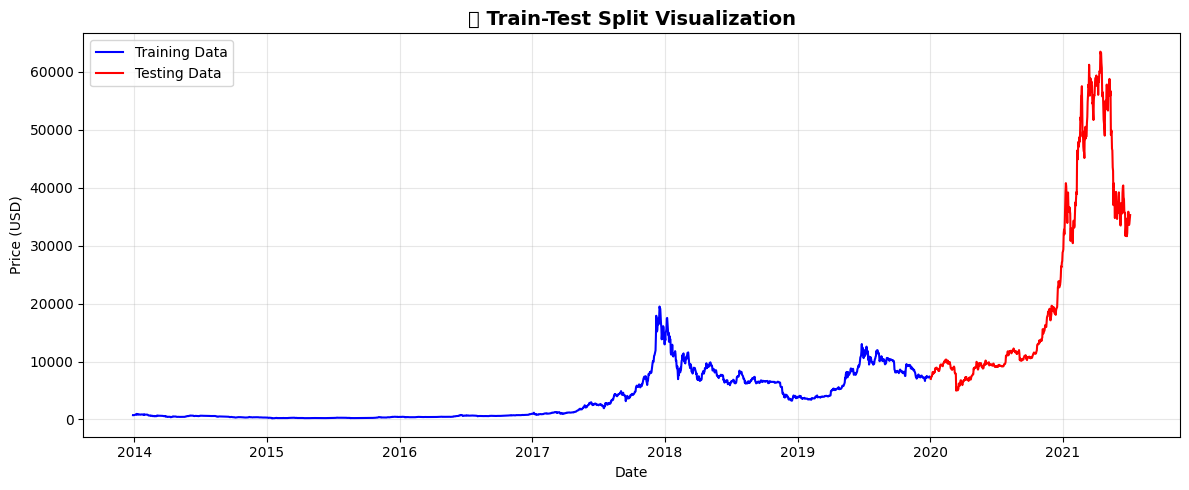

In [ ]:
# Visualizing train-test split distribution
plt.figure(figsize=(12, 5))
plt.plot(df.index[:len(X_train)], df['Close'].iloc[:len(X_train)], label='Training Data', color='blue')
plt.plot(df.index[len(X_train):len(X_train)+len(X_test)], df['Close'].iloc[len(X_train):len(X_train)+len(X_test)], label='Testing Data', color='red')
plt.title('📊 Train-Test Split Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
##8. Classification Models (UP/DOWN Prediction)
---

In [ ]:
# Training Logistic Regression model for binary classification
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train_class)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test_class, log_pred)

print(f" Logistic Regression Accuracy: {log_acc*100:.2f}%")

NameError: name 'LogisticRegression' is not defined

In [ ]:
# Training Decision Tree Classifier for pattern recognition
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train_class)
dt_pred = dt_model.predict(X_test_scaled)
dt_acc = accuracy_score(y_test_class, dt_pred)

print(f" Decision Tree Accuracy: {dt_acc*100:.2f}%")

 Decision Tree Accuracy: 50.00%


In [ ]:
# Training Random Forest Classifier using ensemble of decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train_class)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test_class, rf_pred)

print(f" Random Forest Accuracy: {rf_acc*100:.2f}%")

 Random Forest Accuracy: 46.55%


In [ ]:
# Training Support Vector Machine for complex decision boundaries
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train_class)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test_class, svm_pred)

print(f" SVM Accuracy: {svm_acc*100:.2f}%")

 SVM Accuracy: 47.82%


In [ ]:
# Training K-Nearest Neighbors for similarity-based prediction
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_class)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test_class, knn_pred)

print(f" KNN Accuracy: {knn_acc*100:.2f}%")

 KNN Accuracy: 50.55%


In [ ]:
# Creating Voting Classifier ensemble combining all models
voting_model = VotingClassifier(
    estimators=[('lr', log_model), ('dt', dt_model), ('rf', rf_model),
                ('svm', svm_model), ('knn', knn_model)],
    voting='hard')
voting_model.fit(X_train_scaled, y_train_class)
voting_pred = voting_model.predict(X_test_scaled)
voting_acc = accuracy_score(y_test_class, voting_pred)

print(f" Ensemble (Voting) Accuracy: {voting_acc*100:.2f}%")

 Ensemble (Voting) Accuracy: 46.73%


/tmp/ipykernel_5128/1781170885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_class, palette='viridis')
/tmp/ipykernel_5128/1781170885.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


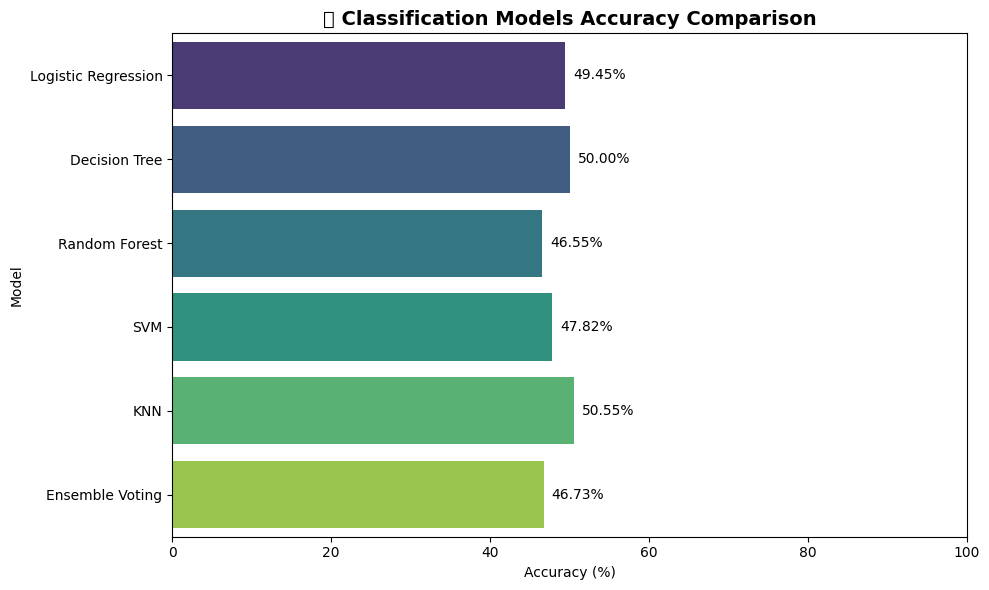

              Model  Accuracy
Logistic Regression 49.454545
      Decision Tree 50.000000
      Random Forest 46.545455
                SVM 47.818182
                KNN 50.545455
    Ensemble Voting 46.727273


In [ ]:
# Comparing all classification models performance
results_class = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Ensemble Voting'],
    'Accuracy': [log_acc*100, dt_acc*100, rf_acc*100, svm_acc*100, knn_acc*100, voting_acc*100]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_class, palette='viridis')
plt.title('📊 Classification Models Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy (%)')
plt.xlim(0, 100)
for i, v in enumerate(results_class['Accuracy']):
    plt.text(v + 1, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()

print(results_class.to_string(index=False))

---
##9. Regression Models (Actual Price Prediction)
---

In [ ]:
# Training Linear Regression for predicting next day's price
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)
lr_pred_reg = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test_reg, lr_pred_reg)
lr_mae = mean_absolute_error(y_test_reg, lr_pred_reg)

print(f" Linear Regression - R² Score: {lr_r2:.4f} | MAE: ${lr_mae:.2f}")

 Linear Regression - R² Score: 0.9948 | MAE: $712.11


In [ ]:
# Training Decision Tree Regressor for capturing non-linear patterns
dt_reg_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_reg_model.fit(X_train_scaled, y_train_reg)
dt_pred_reg = dt_reg_model.predict(X_test_scaled)
dt_r2 = r2_score(y_test_reg, dt_pred_reg)
dt_mae = mean_absolute_error(y_test_reg, dt_pred_reg)

print(f" Decision Tree - R² Score: {dt_r2:.4f} | MAE: ${dt_mae:.2f}")

 Decision Tree - R² Score: -0.0459 | MAE: $10655.87


In [ ]:
# Training Random Forest Regressor for robust price prediction
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_model.fit(X_train_scaled, y_train_reg)
rf_pred_reg = rf_reg_model.predict(X_test_scaled)
rf_r2 = r2_score(y_test_reg, rf_pred_reg)
rf_mae = mean_absolute_error(y_test_reg, rf_pred_reg)

print(f" Random Forest - R² Score: {rf_r2:.4f} | MAE: ${rf_mae:.2f}")

 Random Forest - R² Score: 0.0038 | MAE: $10129.18


In [ ]:
# Training Support Vector Regressor for complex relationships
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_reg)
svr_pred_reg = svr_model.predict(X_test_scaled)
svr_r2 = r2_score(y_test_reg, svr_pred_reg)
svr_mae = mean_absolute_error(y_test_reg, svr_pred_reg)

print(f" SVR - R² Score: {svr_r2:.4f} | MAE: ${svr_mae:.2f}")

 SVR - R² Score: -1.4739 | MAE: $21370.24


In [ ]:
# Training KNN Regressor for similarity-based price prediction
knn_reg_model = KNeighborsRegressor(n_neighbors=5)
knn_reg_model.fit(X_train_scaled, y_train_reg)
knn_pred_reg = knn_reg_model.predict(X_test_scaled)
knn_r2 = r2_score(y_test_reg, knn_pred_reg)
knn_mae = mean_absolute_error(y_test_reg, knn_pred_reg)

print(f" KNN - R² Score: {knn_r2:.4f} | MAE: ${knn_mae:.2f}")

 KNN - R² Score: -0.0028 | MAE: $10632.07


In [ ]:
# Creating Voting Regressor ensemble combining all regression models
voting_reg_model = VotingRegressor(
    estimators=[('lr', lr_model), ('dt', dt_reg_model), ('rf', rf_reg_model),
                ('svr', svr_model), ('knn', knn_reg_model)])
voting_reg_model.fit(X_train_scaled, y_train_reg)
voting_pred_reg = voting_reg_model.predict(X_test_scaled)
voting_r2 = r2_score(y_test_reg, voting_pred_reg)
voting_mae = mean_absolute_error(y_test_reg, voting_pred_reg)

print(f" Ensemble (Voting) - R² Score: {voting_r2:.4f} | MAE: ${voting_mae:.2f}")

 Ensemble (Voting) - R² Score: 0.1682 | MAE: $10433.50


/tmp/ipykernel_5128/1650500987.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score', y='Model', data=results_reg, palette='coolwarm', ax=axes[0])
/tmp/ipykernel_5128/1650500987.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results_reg, palette='magma', ax=axes[1])
/tmp/ipykernel_5128/1650500987.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5128/1650500987.py:17: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N

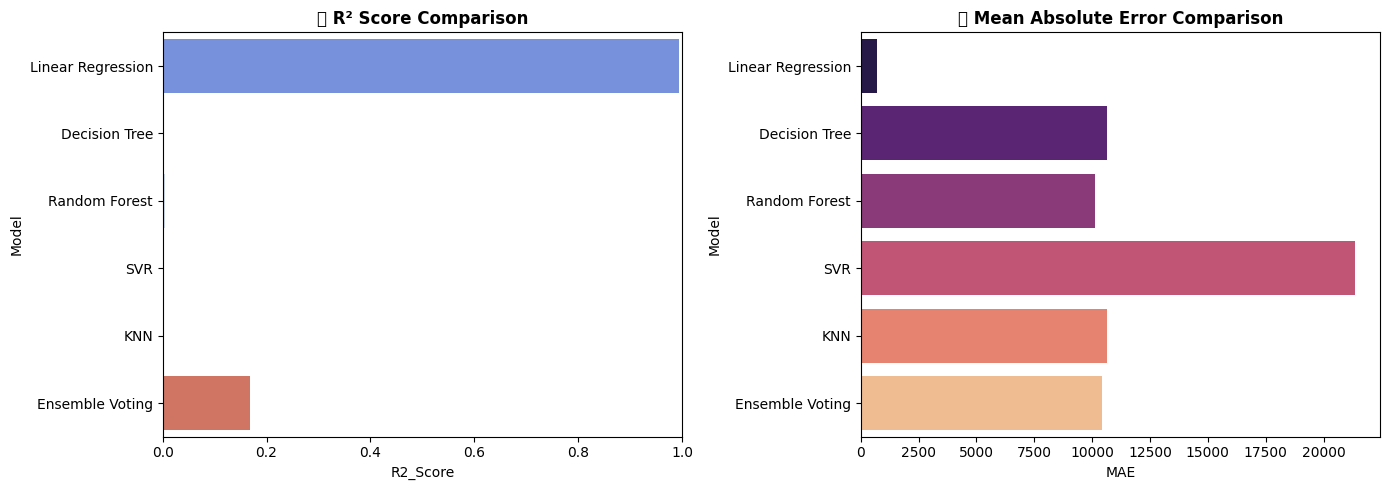

            Model  R2_Score          MAE
Linear Regression  0.994758   712.106472
    Decision Tree -0.045868 10655.871993
    Random Forest  0.003797 10129.182626
              SVR -1.473860 21370.238061
              KNN -0.002774 10632.066475
  Ensemble Voting  0.168192 10433.500458


In [ ]:
# Comparing all regression models performance
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN', 'Ensemble Voting'],
    'R2_Score': [lr_r2, dt_r2, rf_r2, svr_r2, knn_r2, voting_r2],
    'MAE': [lr_mae, dt_mae, rf_mae, svr_mae, knn_mae, voting_mae]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='R2_Score', y='Model', data=results_reg, palette='coolwarm', ax=axes[0])
axes[0].set_title('📊 R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1)

sns.barplot(x='MAE', y='Model', data=results_reg, palette='magma', ax=axes[1])
axes[1].set_title('📉 Mean Absolute Error Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(results_reg.to_string(index=False))

📊 Best Model Visualization & Analysis

In [ ]:
# Finding the best performing models from classification and regression
best_class_model = results_class.loc[results_class['Accuracy'].idxmax()]
best_reg_model = results_reg.loc[results_reg['R2_Score'].idxmax()]

print(" BEST MODELS SUMMARY")
print("="*50)
print(f"\n Best Classification Model: {best_class_model['Model']}")
print(f"   Accuracy: {best_class_model['Accuracy']:.2f}%")
print(f"\n Best Regression Model: {best_reg_model['Model']}")
print(f"   R² Score: {best_reg_model['R2_Score']:.4f}")
print(f"   MAE: ${best_reg_model['MAE']:.2f}")

 BEST MODELS SUMMARY

 Best Classification Model: KNN
   Accuracy: 50.55%

 Best Regression Model: Linear Regression
   R² Score: 0.9948
   MAE: $712.11


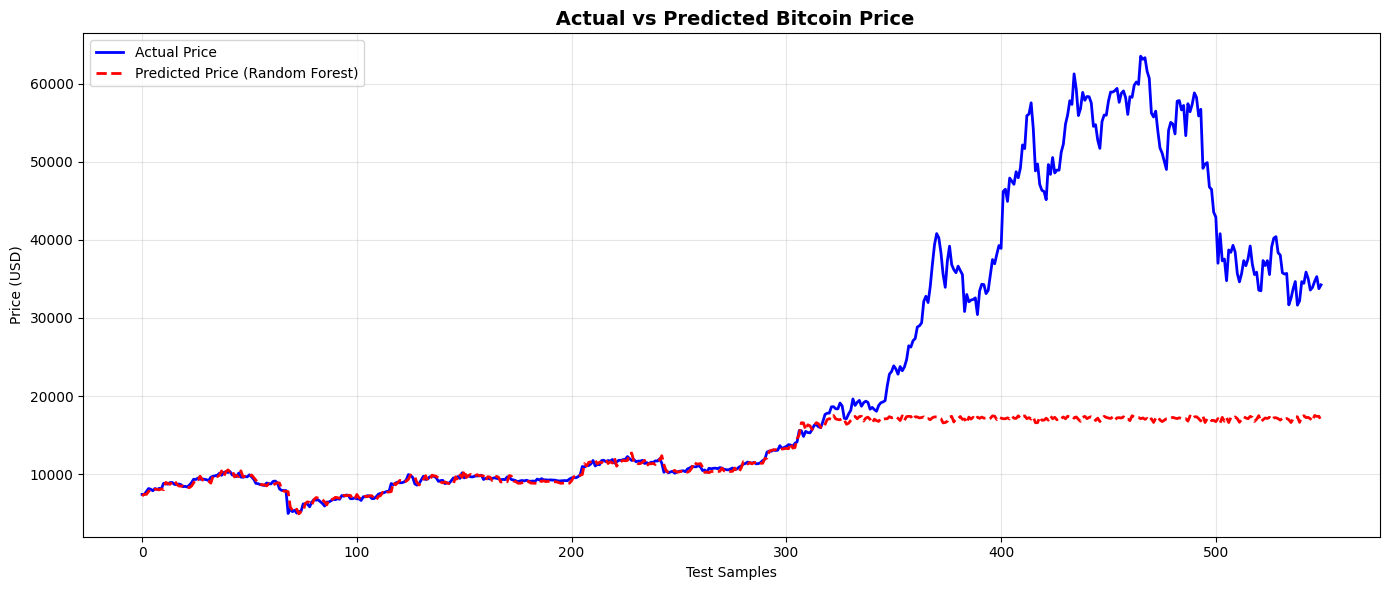

In [ ]:
# Visualizing actual vs predicted prices for best regression model
plt.figure(figsize=(14, 6))
plt.plot(y_test_reg.values, label='Actual Price', color='blue', linewidth=2)
plt.plot(rf_pred_reg, label='Predicted Price (Random Forest)', color='red', linestyle='--', linewidth=2)
plt.title(' Actual vs Predicted Bitcoin Price', fontsize=14, fontweight='bold')
plt.xlabel('Test Samples')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

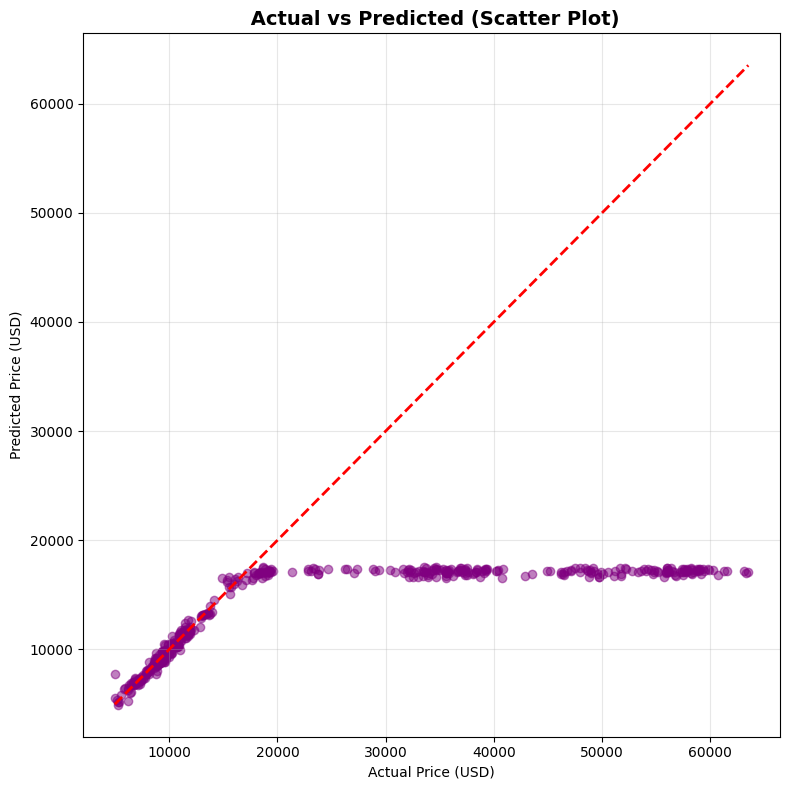

In [ ]:
# Visualizing prediction scatter plot for regression
plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, rf_pred_reg, alpha=0.5, color='purple')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
plt.title(' Actual vs Predicted (Scatter Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

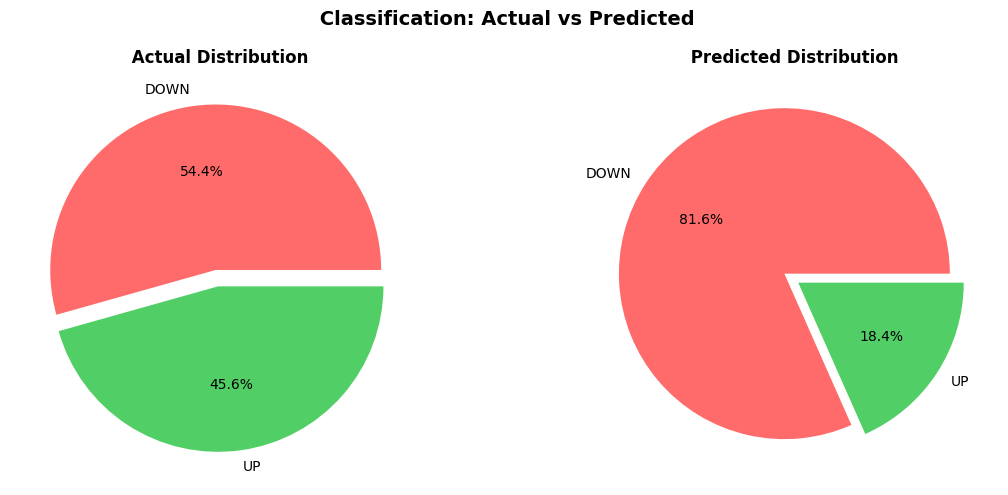

In [ ]:
# Visualizing classification prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(y_test_class.value_counts(), labels=['DOWN', 'UP'], autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'], explode=(0.05, 0.05))
axes[0].set_title(' Actual Distribution', fontsize=12, fontweight='bold')

axes[1].pie(pd.Series(rf_pred).value_counts(), labels=['DOWN', 'UP'], autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'], explode=(0.05, 0.05))
axes[1].set_title(' Predicted Distribution', fontsize=12, fontweight='bold')

plt.suptitle(' Classification: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

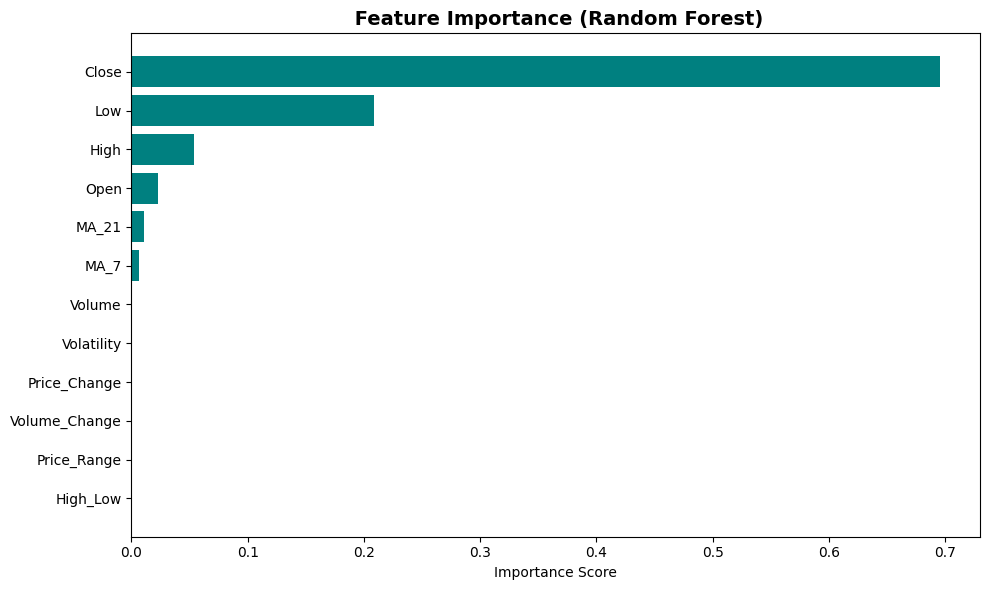

In [ ]:
# Visualizing feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_reg_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.title(' Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

📋 Classification Report & Final Metrics

In [ ]:
# Generating detailed classification report for best model
from sklearn.metrics import confusion_matrix

print(" CLASSIFICATION REPORT (Random Forest)")
print("="*55)
print(classification_report(y_test_class, rf_pred, target_names=['DOWN', 'UP']))

 CLASSIFICATION REPORT (Random Forest)
              precision    recall  f1-score   support

        DOWN       0.45      0.81      0.58       251
          UP       0.52      0.18      0.27       299

    accuracy                           0.47       550
   macro avg       0.49      0.49      0.42       550
weighted avg       0.49      0.47      0.41       550



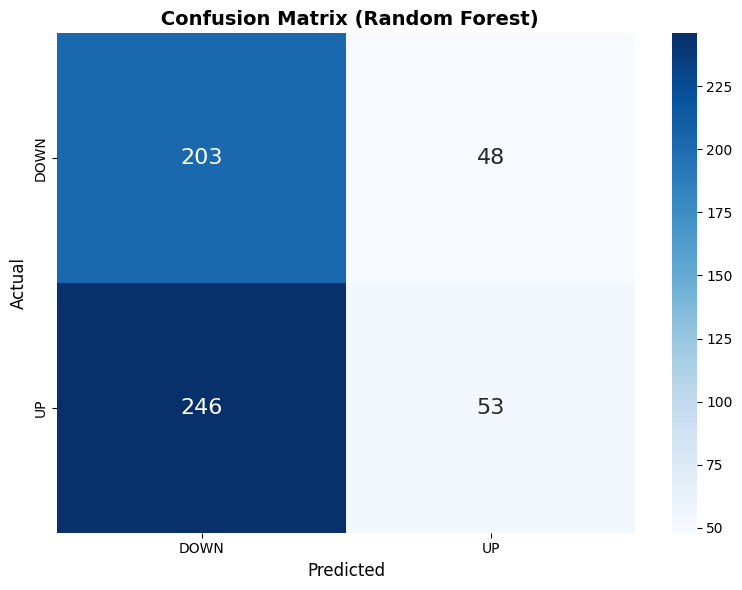

 True Negatives (DOWN correct): 203
 True Positives (UP correct): 53
 False Positives: 48
 False Negatives: 246


In [ ]:
# Visualizing confusion matrix for classification model
cm = confusion_matrix(y_test_class, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN', 'UP'], yticklabels=['DOWN', 'UP'],
            annot_kws={'size': 16})
plt.title(' Confusion Matrix (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

print(f" True Negatives (DOWN correct): {cm[0][0]}")
print(f" True Positives (UP correct): {cm[1][1]}")
print(f" False Positives: {cm[0][1]}")
print(f" False Negatives: {cm[1][0]}")

In [ ]:
# Generating detailed regression metrics for best model
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_reg, rf_pred_reg))
mape = np.mean(np.abs((y_test_reg - rf_pred_reg) / y_test_reg)) * 100

print(" REGRESSION METRICS (Random Forest)")
print("="*50)
print(f" R² Score: {rf_r2:.4f}")
print(f" MAE (Mean Absolute Error): ${rf_mae:.2f}")
print(f" RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f" MAPE (Mean Absolute % Error): {mape:.2f}%")

 REGRESSION METRICS (Random Forest)
 R² Score: 0.0038
 MAE (Mean Absolute Error): $10129.18
 RMSE (Root Mean Squared Error): $17625.78
 MAPE (Mean Absolute % Error): 23.64%


In [ ]:
# Creating final summary comparison table
print(" FINAL MODEL COMPARISON SUMMARY")
print("="*60)

print("\n CLASSIFICATION MODELS:")
print(results_class.to_string(index=False))

print("\n REGRESSION MODELS:")
print(results_reg.to_string(index=False))

 FINAL MODEL COMPARISON SUMMARY

 CLASSIFICATION MODELS:
              Model  Accuracy
Logistic Regression 49.454545
      Decision Tree 50.000000
      Random Forest 46.545455
                SVM 47.818182
                KNN 50.545455
    Ensemble Voting 46.727273

 REGRESSION MODELS:
            Model  R2_Score          MAE
Linear Regression  0.994758   712.106472
    Decision Tree -0.045868 10655.871993
    Random Forest  0.003797 10129.182626
              SVR -1.473860 21370.238061
              KNN -0.002774 10632.066475
  Ensemble Voting  0.168192 10433.500458


/tmp/ipykernel_5128/3025955790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_class, palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_5128/3025955790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score', y='Model', data=results_reg, palette='coolwarm', ax=axes[0, 1])


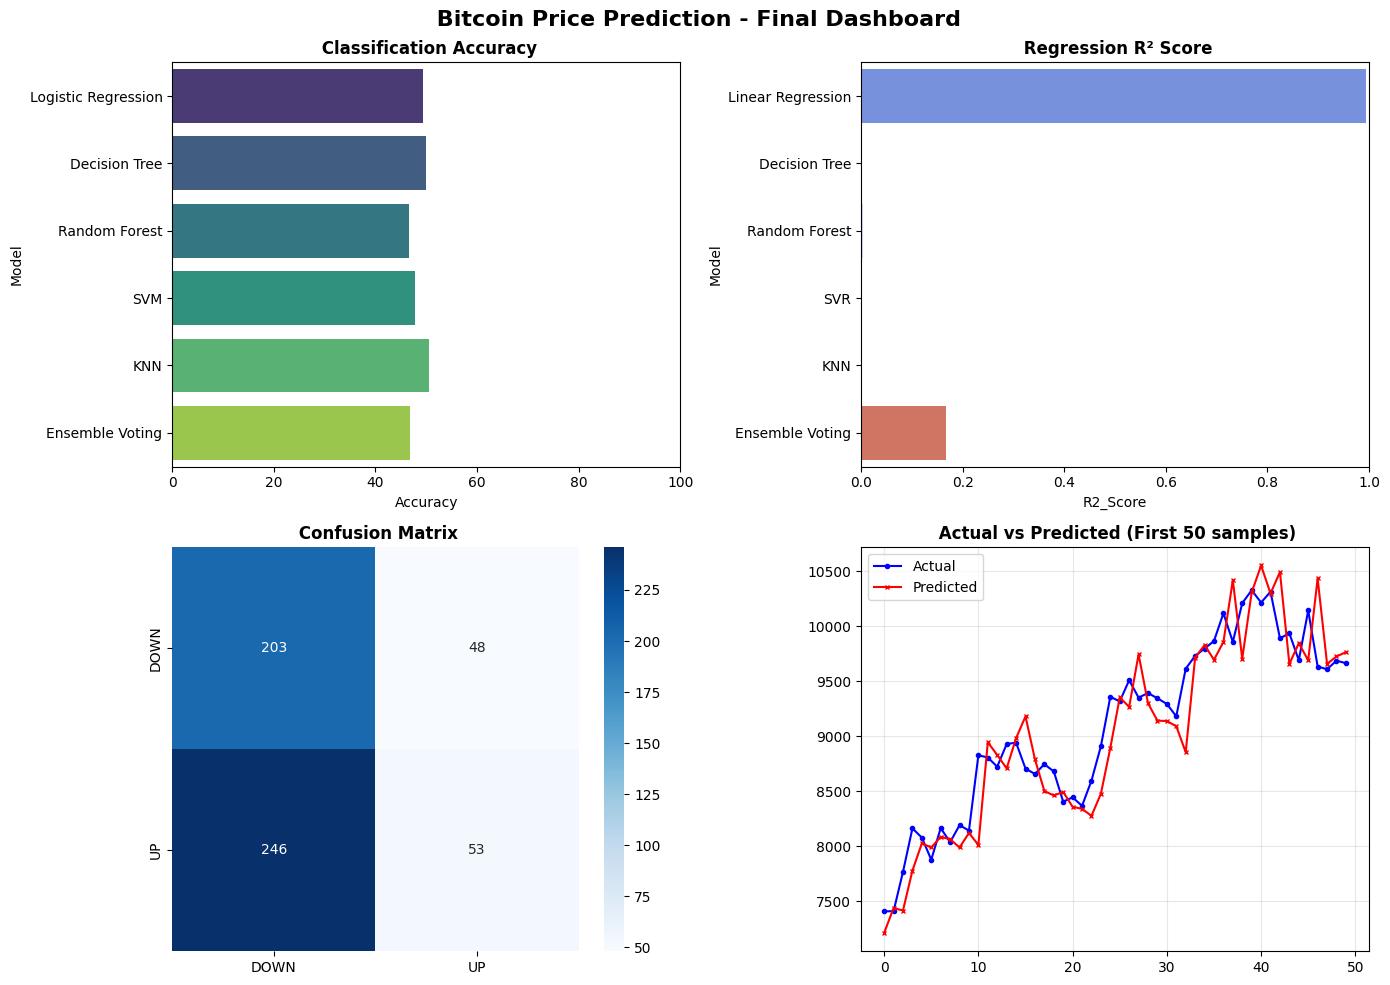

In [ ]:
# Visualizing final comparison dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Classification Accuracy
sns.barplot(x='Accuracy', y='Model', data=results_class, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title(' Classification Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlim(0, 100)

# Plot 2: Regression R² Score
sns.barplot(x='R2_Score', y='Model', data=results_reg, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title(' Regression R² Score', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(0, 1)

# Plot 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['DOWN', 'UP'], yticklabels=['DOWN', 'UP'])
axes[1, 0].set_title(' Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 4: Actual vs Predicted
axes[1, 1].plot(y_test_reg.values[:50], label='Actual', color='blue', marker='o', markersize=3)
axes[1, 1].plot(rf_pred_reg[:50], label='Predicted', color='red', marker='x', markersize=3)
axes[1, 1].set_title(' Actual vs Predicted (First 50 samples)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle(' Bitcoin Price Prediction - Final Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

🔮 Making Predictions on New Data

In [ ]:
# Creating a sample prediction function for new data
def predict_bitcoin_price(model_class, model_reg, scaler, last_data):
    """Function to predict both direction and price for next day"""
    last_data_scaled = scaler.transform(last_data)

    direction_pred = model_class.predict(last_data_scaled)
    price_pred = model_reg.predict(last_data_scaled)

    direction = "📈 UP" if direction_pred[0] == 1 else "📉 DOWN"

    return direction, price_pred[0]

print(" Prediction function created successfully!")

✅ Prediction function created successfully!


In [ ]:
# Making prediction on the last available data
last_sample = X_test.tail(1)

direction, predicted_price = predict_bitcoin_price(rf_model, rf_reg_model, scaler, last_sample)
actual_price = y_test_reg.iloc[-1]

print(" NEXT DAY PREDICTION")
print("="*50)
print(f" Based on last test sample")
print(f" Current Price: ${actual_price:.2f}")
print(f" Predicted Price: ${predicted_price:.2f}")
print(f" Direction: {direction}")
print(f" Price Change: ${predicted_price - actual_price:.2f}")
print(f" % Change: {((predicted_price - actual_price) / actual_price * 100):.2f}%")

 NEXT DAY PREDICTION
 Based on last test sample
 Current Price: $34235.19
 Predicted Price: $16867.73
 Direction: 📉 DOWN
 Price Change: $-17367.46
 % Change: -50.73%


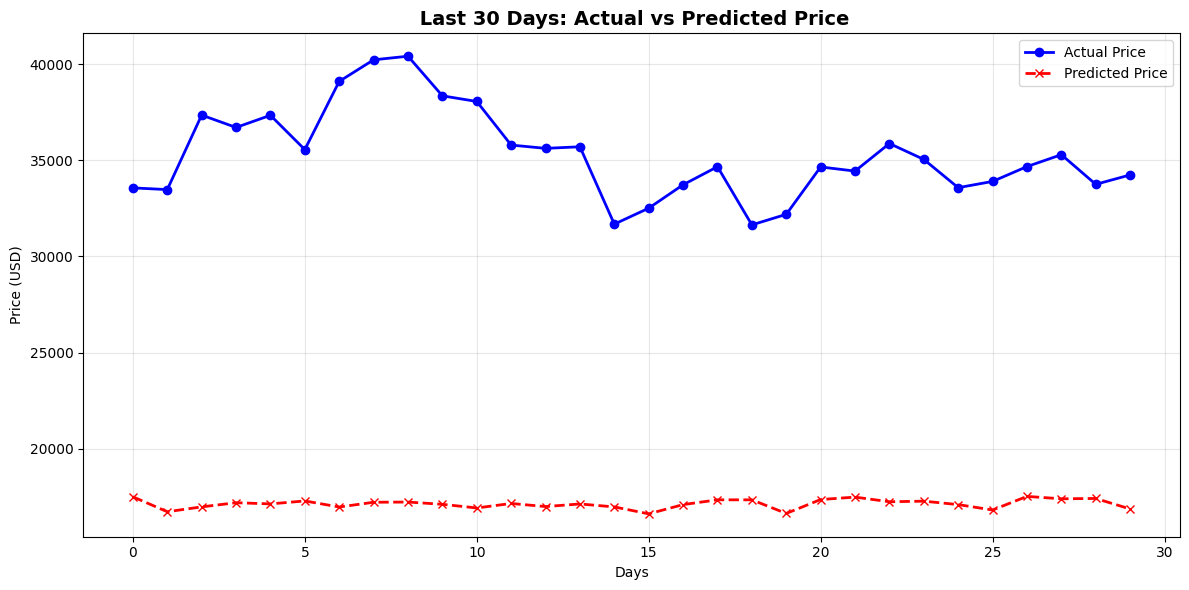

In [ ]:
# Visualizing last 30 days prediction vs actual
last_30_actual = y_test_reg.tail(30).values
last_30_pred = rf_pred_reg[-30:]

plt.figure(figsize=(12, 6))
plt.plot(range(30), last_30_actual, marker='o', label='Actual Price', color='blue', linewidth=2)
plt.plot(range(30), last_30_pred, marker='x', label='Predicted Price', color='red', linewidth=2, linestyle='--')
plt.title(' Last 30 Days: Actual vs Predicted Price', fontsize=14, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Creating prediction summary for multiple test samples
prediction_summary = pd.DataFrame({
    'Actual_Price': y_test_reg.tail(10).values,
    'Predicted_Price': rf_pred_reg[-10:],
    'Actual_Direction': y_test_class.tail(10).map({0: 'DOWN', 1: 'UP'}).values,
    'Predicted_Direction': rf_pred[-10:].astype(int)
})
prediction_summary['Predicted_Direction'] = prediction_summary['Predicted_Direction'].map({0: 'DOWN', 1: 'UP'})
prediction_summary['Error'] = prediction_summary['Predicted_Price'] - prediction_summary['Actual_Price']
prediction_summary['Error_%'] = (prediction_summary['Error'] / prediction_summary['Actual_Price'] * 100).round(2)

print(" LAST 10 PREDICTIONS SUMMARY")
print("="*80)
print(prediction_summary.to_string(index=False))

 LAST 10 PREDICTIONS SUMMARY
 Actual_Price  Predicted_Price Actual_Direction Predicted_Direction         Error  Error_%
 34649.644588     17358.973867               UP                DOWN -17290.670720   -49.90
 34434.335314     17485.303896             DOWN                DOWN -16949.031418   -49.22
 35867.777735     17243.841807               UP                DOWN -18623.935929   -51.92
 35040.837249     17274.228838             DOWN                DOWN -17766.608411   -50.70
 33572.117653     17095.445820             DOWN                DOWN -16476.671832   -49.08
 33897.048590     16814.905801               UP                DOWN -17082.142789   -50.39
 34668.548402     17522.162812               UP                DOWN -17146.385589   -49.46
 35287.779766     17397.246904               UP                DOWN -17890.532862   -50.70
 33746.002456     17414.273877             DOWN                DOWN -16331.728579   -48.40
 34235.193451     16867.729854               UP              

In [ ]:
# Saving the best models for future use
import pickle

pickle.dump(rf_model, open('bitcoin_classifier.pkl', 'wb'))
pickle.dump(rf_reg_model, open('bitcoin_regressor.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print(" Models saved successfully!")
print(" Files created:")
print("   - bitcoin_classifier.pkl")
print("   - bitcoin_regressor.pkl")
print("   - scaler.pkl")

 Models saved successfully!
 Files created:
   - bitcoin_classifier.pkl
   - bitcoin_regressor.pkl
   - scaler.pkl
